In [1]:
# Libraries
import pyvisa                    # Communication (also install pyvisa-py or NI VISA)
import matplotlib.pyplot as plt  # Plots
import numpy as np               # Maths
import pandas as pd              # DataFrames
import time                      # Delays
from tqdm.notebook import tqdm   # Progress bars (use 'for i in tqdm(iter)')
import os                        # Used for determining platform
import sys                       # Used for local import setup
sys.path.append(r"../../")       # Used for local imports

In [2]:
from Utilities.SetupLogging import setupLogging
logger = setupLogging()

In [3]:
from Devices.SRS import SR850
from Devices.Coherent import SapphireLP, CUBE
from Devices.PM100 import PM100
from Devices.Keithley import SourceMeter2400
from Devices.QuantumDesign import PPMS

In [4]:
rm = pyvisa.ResourceManager()

lockin = SR850(rm, 'GPIB1::14::INSTR')
laser = CUBE(rm, address='ASRL1::INSTR')
pm = PM100(rm, 'USB0::0x1313::0x8078::P0017770::INSTR', attName='ppms-tap')
sm = SourceMeter2400(rm, sn='04085563')
ppms = PPMS("8fvfvd3.dhcp.nd.edu")

WARNING	- instrumpy.CUBE - Config entry does not contain a limit key or entry is missing. User limits are disabled.


In [5]:
data = {}

In [6]:
data['wavelength_nm'] = 530
data['laser_setpoint_mW'] = 330
data['current_setpoint_uA'] = 10

In [8]:
laser.power = data['laser_setpoint_mW']
pm.wavelength = data['wavelength_nm']
time.sleep(10)
data['light_on_sample_mW'] = float(pm.power*1e3)
data['chopper_freq_Hz'] = lockin.getFreq()
sm.setCC(data['current_setpoint_uA']*1e-6, 1)

In [9]:
data

{'wavelength_nm': 530,
 'laser_setpoint_mW': 330,
 'current_setpoint_uA': 10,
 'light_on_sample_mW': 37.65754489929007,
 'chopper_freq_Hz': 223.413}

In [15]:
temp_upper = 300
temp_lower = 10
data['temp_rate_Kpermin'] = 2

data['cooldown_temps_K'] = []
data['cooldown_sigs_V'] = []
data['cooldown_thetas'] = []
data['cooldown_curr_uA'] = []

T, _ = ppms.getTemperature()
if T < temp_upper:
    ppms.setTemperature(temp_upper, data['temp_rate_Kpermin'], True)
    ppms.waitFor(temp = True, timeout = 3600)

print('PPMS at starting temp, starting cooldown')
ppms.setTemperature(temp_lower, data['temp_rate_Kpermin'], True)

while True:
    T, _ = ppms.getTemperature()
    R, theta = lockin.snapshot('R', 'THETA')
    I = sm.I

    data['cooldown_temps_K'].append(T)
    data['cooldown_sigs_V'].append(R)
    data['cooldown_thetas'].append(theta)
    data['cooldown_curr_uA'].append(I*1e6)

    if ppms.isSteady(temp = True):
        break

    time.sleep(15)

print('Cooldown cycle complete, starting heatup')
ppms.setTemperature(temp_upper, data['temp_rate_Kpermin'], True)

data['heatup_temps_K'] = []
data['heatup_sigs_V'] = []
data['heatup_thetas'] = []
data['heatup_curr_uA'] = []

while True:
    T, _ = ppms.getTemperature()
    R, theta = lockin.snapshot('R', 'THETA')
    I = sm.I

    data['heatup_temps_K'].append(T)
    data['heatup_sigs_V'].append(R)
    data['heatup_thetas'].append(theta)
    data['heatup_curr_uA'].append(I*1e6)

    if ppms.isSteady(temp = True):
        break

    time.sleep(15)

PPMS at starting temp, starting cooldown
Cooldown cycle complete, starting heatup


In [16]:
data

{'wavelength_nm': 530,
 'laser_setpoint_mW': 330,
 'current_setpoint_uA': 10,
 'light_on_sample_mW': 37.65754489929007,
 'chopper_freq_Hz': 223.413,
 'temp_rate_Kpermin': 2,
 'cooldown_temps_K': [301.89892578125,
  301.83984375,
  301.8514404296875,
  301.9584045410156,
  302.04742431640625,
  302.0657958984375,
  302.0086975097656,
  301.8717956542969,
  301.6631164550781,
  301.4022216796875,
  301.0935363769531,
  300.75360107421875,
  300.3802490234375,
  299.9869689941406,
  299.5724182128906,
  299.1416015625,
  298.6822204589844,
  298.2178039550781,
  297.7423095703125,
  297.25811767578125,
  296.76336669921875,
  296.2715759277344,
  295.7586975097656,
  295.2593994140625,
  294.7535400390625,
  294.2471923828125,
  293.71142578125,
  293.2225646972656,
  292.6958312988281,
  292.1717529296875,
  291.65057373046875,
  291.12164306640625,
  290.6082763671875,
  290.09735107421875,
  289.57489013671875,
  289.05029296875,
  288.5245666503906,
  287.966064453125,
  287.427886962

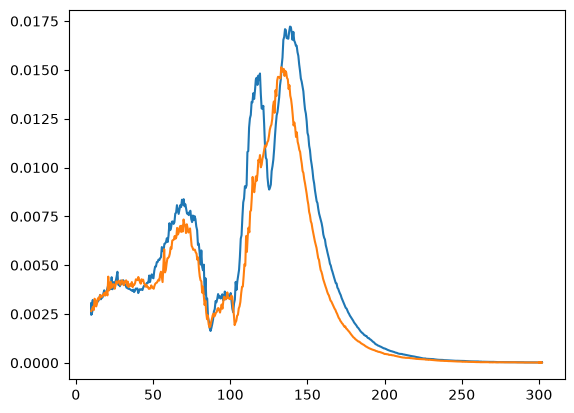

In [19]:
plt.plot(data['cooldown_temps_K'], data['cooldown_sigs_V'])
plt.plot(data['heatup_temps_K'], data['heatup_sigs_V'])
plt.show()

In [20]:
data['cooldown_temps_K'][np.argmax(data['cooldown_sigs_V'])]

138.76449584960938

In [22]:
ppms.setTemperature(300, 3, True)

In [9]:
pm.wavelength = 661

In [40]:
laser.power = 10

In [41]:
pm.power*1e6

np.float64(1531.8655673660476)

In [19]:
import json

In [33]:
import json
with open('../../Data/MoS2_temp_dependent_photocond.json', 'w') as f:
    json.dump(data, f)

In [48]:
setpoint = 8

laser.power = setpoint
time.sleep(5)
print(f'{pm.power*1e3} mW')

1.1699456966002935 mW
